In [1]:
from torchvision import datasets
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
from torch.optim import Adam
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# define o dispositivo
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cpu


In [5]:
# baixa o dataset FashionMNIST de treino e validação
data_folder = '~/data/FMNIST'
fmnist     = datasets.FashionMNIST(data_folder, download=True, train=True)
val_fmnist = datasets.FashionMNIST(data_folder, download=True, train=False)

# separa imagens e rótulos de cada split
tr_images,  tr_targets  = fmnist.data,     fmnist.targets
val_images, val_targets = val_fmnist.data, val_fmnist.targets

print( tr_images.shape, '|', val_images.shape)

100%|██████████| 5.15k/5.15k [00:00<00:00, 5.57MB/s]

torch.Size([60000, 28, 28]) | torch.Size([10000, 28, 28])


In [8]:
# dataset que converte cada imagem 28x28
class FMNISTDataset(Dataset):
    def __init__(self, x, y):
        x = x.float()
        x = x.view(-1, 28*28) / 255 # achata e normaliza
        self.x, self.y = x, y

    def __getitem__(self, ix):

        return self.x[ix].to(device), self.y[ix].to(device) # retorna a amostra movida

    def __len__(self):
        return len(self.x)

In [9]:
# cria os dataloaders
def get_data():
    trn_dl = DataLoader(FMNISTDataset(tr_images, tr_targets),   batch_size=32, shuffle=True)
    val_dl = DataLoader(FMNISTDataset(val_images, val_targets), batch_size=len(val_images), shuffle=False)
    return trn_dl, val_dl

In [10]:
# rede profunda com duas camadas ocultas
def get_model():
    model = nn.Sequential(
        nn.Linear(28*28, 1000), # camada de entrada
        nn.ReLU(), # ativação
        nn.Linear(1000, 1000), # camada oculta
        nn.ReLU(), # ativação
        nn.Linear(1000, 10) # saída com 10 classes
    ).to(device)
    loss_fn   = nn.CrossEntropyLoss() # perda para classificação
    optimizer = Adam(model.parameters(), lr=1e-3) # otimizador adam
    return model, loss_fn, optimizer

In [11]:
# treina um batch e retorna o valor do erro
def train_batch(x, y, model, opt, loss_fn):
    model.train() # modo de treino
    prediction = model(x) # forward pass
    batch_loss = loss_fn(prediction, y) # calcula o erro
    batch_loss.backward() # backward pass
    opt.step() # atualiza os pesos
    opt.zero_grad() # limpa os gradientes
    return batch_loss.item()

# calcula a acuracia
@torch.no_grad()
def accuracy(x, y, model):
    model.eval()
    prediction = model(x)
    _, argmaxes = prediction.max(-1)
    return (argmaxes == y).cpu().numpy().tolist()

# calcula o erro na validaçao
@torch.no_grad()
def val_loss(x, y, model, loss_fn):
    model.eval()
    return loss_fn(model(x), y).item()

In [12]:
# instancia dados
trn_dl, val_dl = get_data()
model, loss_fn, optimizer = get_model()

In [14]:
# loop de treinamento
train_losses, train_accuracies = [], []
val_losses,   val_accuracies   = [], []

for epoch in range(5):
    print(f'{epoch+1}/5')
    epoch_losses, epoch_accs = [], []

    # passa por todos os batches
    for x, y in trn_dl:
        epoch_losses.append(train_batch(x, y, model, optimizer, loss_fn))

    # acuracia no treino
    for x, y in trn_dl:
        epoch_accs.extend(accuracy(x, y, model))

    # metricas de validação
    for x, y in val_dl:
        v_acc  = accuracy(x, y, model)
        v_loss = val_loss(x, y, model, loss_fn)

    # armazena as medias da epoca
    train_losses.append(np.mean(epoch_losses))
    train_accuracies.append(np.mean(epoch_accs))
    val_losses.append(v_loss)
    val_accuracies.append(np.mean(v_acc))

1/5
2/5
3/5
4/5
5/5


NameError: name 'mticker' is not defined

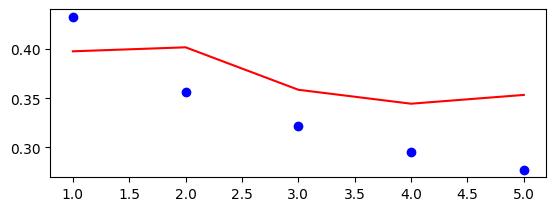

In [15]:
# plota as curvas de perda e acuracia
epochs = np.arange(5) + 1

plt.subplot(211)
plt.plot(epochs, train_losses, 'bo', label='Treino')
plt.plot(epochs, val_losses,   'r',  label='Validação')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Perda — treino vs validação')
plt.xlabel('Épocas'); plt.ylabel('Loss')
plt.legend(); plt.grid(True)

plt.subplot(212)
plt.plot(epochs, train_accuracies, 'bo', label='Treino')
plt.plot(epochs, val_accuracies,   'r',  label='Validação')
plt.gca().xaxis.set_major_locator(mticker.MultipleLocator(1))
plt.title('Acurácia — treino vs validação')
plt.xlabel('Épocas'); plt.ylabel('Acurácia')
plt.gca().set_yticklabels(['{:.0f}%'.format(x*100) for x in plt.gca().get_yticks()])
plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()